# Fold-split Gold Temporal Relation Graphs — Demo (TDDMan)

**Real-text TimeML corpora → schema-validated, document-level gold temporal relation graphs.**

This dataset ships frozen, reusable per-document **gold temporal relation graphs** that
downstream real-text temporal-closure experiments consume. Each row is one
`(corpus, document)`: `input` = the document text, `output` = a JSON gold graph
(`nodes` + `edges`, each edge carrying a canonical relation-algebra set, locality metadata
and a fold label).

Three corpora play three roles:
- **NarrativeTime** — the *dense* headline host (full TLink coverage, ~1.58M triangles).
- **TDDMan** — the *non-circularity anchor*: 99.9% of its pairs are **long-distance**
  (≥2 sentences apart), manually annotated and provably not auto-inferable from a local window.
- **MATRES** — the *gate-validation control* with a near-empty deduction envelope (0% long-distance).

This demo loads the **TDDMan** subset (small, clean graphs that best show the long-distance,
multi-hop structure), then **re-runs the dataset's own descriptive-structural-counts code**
(`counts.py`) on each gold graph — reproducing the shipped `metadata_descriptive_counts`
exactly — and finally **visualizes** one document's temporal relation graph.

> Only *descriptive* structural counts are computed here (sizes, label/locality distributions,
> triangles, cyclomatic number, multi-hop pairs). The *gated* statistics (deduction-required
> `N*`, bite-after-widening, singleton-resolution) require composition-table closure and are the
> downstream experiment's job.

In [1]:
# --- Install dependencies (Colab-safe) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# networkx + matplotlib are pre-installed on Colab; install locally at Colab's versions
# so a local run mirrors the Colab environment. (json / collections are stdlib.)
if 'google.colab' not in sys.modules:
    _pip('networkx==3.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports ---
# Stdlib + the two libraries the descriptive-counts code uses, plus matplotlib for the viz.
import json
import collections

import networkx as nx
import matplotlib.pyplot as plt

In [3]:
# --- Data loading helper (GitHub URL with local fallback for Colab) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-1/dataset-1/demo/mini_demo_data.json"
import os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

# Top-level schema is {metadata, datasets}; datasets is a list grouped by corpus.
group = data["datasets"][0]                       # the single TDDMan group in this demo subset
examples = group["examples"]
print("corpus            :", group["dataset"])
print("documents in demo :", len(examples))
print("source            :", data["metadata"]["sources"]["tddman"][:90], "...")
print("fold scheme       :", data["metadata"]["fold"][:90], "...")

corpus            : tddman
documents in demo : 10
source            : https://github.com/aakanksha19/TDDiscourse (TDDiscourse, Naik et al. SIGDIAL 2019), TDDMan ...
fold scheme       : Document-level fold = TimeBank-Dense 22/5/9 split (train/dev/test) for NT/TDDMan/TBD; MATR ...


## Configuration

All tunable parameters live here. They start at small values so the demo runs fast; raise
`N_DOCS` toward `len(examples)` to analyze the whole demo subset.

In [5]:
# --- Config (tunable) ---
# How many TDDMan documents to analyze. Minimum that produces output is 1.
# The demo subset has 10 documents; analyzing all of them runs in well under a second.
N_DOCS = 10                 # MIN to start: 2 ; full demo subset: len(examples) == 10 (used here)

# Deterministic layout seed for the temporal-graph visualization.
RANDOM_SEED = 7

# Cap node count in the drawn graph so the picture stays readable.
MAX_VIZ_NODES = 40

N_DOCS = min(N_DOCS, len(examples))
print(f"Analyzing {N_DOCS} of {len(examples)} demo documents.")

Analyzing 10 of 10 demo documents.


## The dataset's descriptive-counts code (`counts.py`, verbatim)

These pure-graph descriptors are exactly the functions used to build the shipped
`metadata_descriptive_counts`. They compute sizes, native/canonical label distributions,
locality distribution, and the **structural** signals that motivate the dataset: triangle
count, cyclomatic number, query edges with ≥2 common intermediates, and pairs reachable only
via a path of length ≥3 (genuine multi-hop deduction structure). An edge is *informative* iff
its canonical relation set is not the full disjunction (i.e. it actually constrains the order).

In [6]:
# ===== counts.py (verbatim) ===============================================
def _is_informative(edge: dict) -> bool:
    """An edge carries a temporal constraint iff its canonical set is not the full
    disjunction. NarrativeTime/MATRES/TBD use the native label 'VAGUE'; TDDMan has none."""
    nr = str(edge.get("native_relation", "")).upper()
    if nr == "VAGUE":
        return False
    cset = edge.get("canonical_relation_set") or []
    # full Allen (13) or full point (3) == no constraint
    if len(cset) >= 13:
        return False
    if edge.get("canonical_algebra") == "point" and len(cset) >= 3:
        return False
    return True


def _structural(nodes_by_id: dict, edges: list, restrict_event_event: bool) -> dict:
    G = nx.Graph()
    type_of = {nid: n["node_type"] for nid, n in nodes_by_id.items()}
    for e in edges:
        if not _is_informative(e):
            continue
        u, v = e["source"], e["target"]
        if restrict_event_event:
            if type_of.get(u) != "event" or type_of.get(v) != "event":
                continue
        if u == v:
            continue
        G.add_edge(u, v)
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    if n_nodes == 0:
        return {"n_informative_edges": 0, "n_nodes_in_graph": 0, "n_triangles": 0,
                "n_query_edges_ge2_intermediates": 0, "cyclomatic_number": 0,
                "n_pairs_path_len_ge3": 0, "max_node_degree": 0}
    tri = sum(nx.triangles(G).values()) // 3
    ge2 = 0
    for u, v in G.edges():
        common = len(set(G[u]) & set(G[v]))
        if common >= 2:
            ge2 += 1
    cyclo = n_edges - n_nodes + nx.number_connected_components(G)
    # pairs reachable only via a path of length >= 3 (genuine multi-hop deduction structure)
    ge3 = 0
    for src, lengths in nx.all_pairs_shortest_path_length(G):
        for dst, d in lengths.items():
            if src < dst and d >= 3:
                ge3 += 1
    degs = [d for _, d in G.degree()]
    return {
        "n_informative_edges": n_edges,
        "n_nodes_in_graph": n_nodes,
        "n_triangles": tri,
        "n_query_edges_ge2_intermediates": ge2,
        "cyclomatic_number": cyclo,
        "n_pairs_path_len_ge3": ge3,
        "max_node_degree": max(degs) if degs else 0,
    }


def descriptive_counts(record: dict) -> dict:
    nodes = record["nodes"]
    edges = record["edges"]
    nodes_by_id = {n["node_id"]: n for n in nodes}

    n_events = sum(1 for n in nodes if n["node_type"] == "event")
    n_timex = sum(1 for n in nodes if n["node_type"] == "timex")
    n_dct = sum(1 for n in nodes if n["node_type"] == "dct")

    native = collections.Counter(str(e.get("native_relation")) for e in edges)
    canon = collections.Counter("|".join(e.get("canonical_relation_set") or []) for e in edges)
    loc = collections.Counter(e.get("locality_class") for e in edges)
    n_ee = sum(1 for e in edges
               if nodes_by_id.get(e["source"], {}).get("node_type") == "event"
               and nodes_by_id.get(e["target"], {}).get("node_type") == "event")
    vw = sum(1 for e in edges if e.get("vague_widened"))

    return {
        "n_documents": 1,
        "n_events": n_events,
        "n_timex": n_timex,
        "n_dct": n_dct,
        "n_nodes": len(nodes),
        "n_edges": len(edges),
        "n_edges_event_event": n_ee,
        "native_relation_dist": dict(native),
        "canonical_relation_set_dist": dict(canon),
        "sentence_distance_dist": {
            "intra": loc.get("intra", 0),
            "adjacent": loc.get("adjacent", 0),
            "long_distance": loc.get("long_distance", 0),
            "undefined": loc.get("undefined", 0),
        },
        "vague_widened_count": vw,
        "structure_event_event_informative": _structural(nodes_by_id, edges, restrict_event_event=True),
        "structure_all_nodes_informative": _structural(nodes_by_id, edges, restrict_event_event=False),
    }


def aggregate_counts(per_doc: list) -> dict:
    """Sum / merge per-document descriptive counts into a corpus-level summary."""
    agg = {
        "n_documents": len(per_doc),
        "n_events": 0, "n_timex": 0, "n_dct": 0, "n_nodes": 0, "n_edges": 0,
        "n_edges_event_event": 0, "vague_widened_count": 0,
        "native_relation_dist": collections.Counter(),
        "sentence_distance_dist": collections.Counter(),
        "structure_event_event_informative": collections.Counter(),
        "structure_all_nodes_informative": collections.Counter(),
    }
    for d in per_doc:
        for k in ["n_events", "n_timex", "n_dct", "n_nodes", "n_edges",
                  "n_edges_event_event", "vague_widened_count"]:
            agg[k] += d[k]
        agg["native_relation_dist"].update(d["native_relation_dist"])
        agg["sentence_distance_dist"].update(d["sentence_distance_dist"])
        for sk in ["structure_event_event_informative", "structure_all_nodes_informative"]:
            for k, v in d[sk].items():
                agg[sk][k] += v
    for k in ["native_relation_dist", "sentence_distance_dist",
              "structure_event_event_informative", "structure_all_nodes_informative"]:
        agg[k] = dict(agg[k])
    # locality fraction (the headline descriptor: long-distance share)
    sd = agg["sentence_distance_dist"]
    tot = sum(sd.values()) or 1
    agg["long_distance_fraction"] = round(sd.get("long_distance", 0) / tot, 4)
    agg["adjacent_fraction"] = round(sd.get("adjacent", 0) / tot, 4)
    agg["intra_fraction"] = round(sd.get("intra", 0) / tot, 4)
    return agg
# ==========================================================================

## Parse each gold graph and recompute its descriptive counts

Each example's `output` field is `json.dumps(gold_graph)` — we parse it with
`json.loads`. We then run `descriptive_counts` on the parsed graph and check it reproduces the
`metadata_descriptive_counts` that shipped with the example (a built-in reproducibility check).

In [7]:
records = []          # parsed gold graphs
per_doc = []          # recomputed descriptive counts

for ex in examples[:N_DOCS]:
    record = json.loads(ex["output"])          # parse the gold graph string
    counts = descriptive_counts(record)        # re-run the dataset's own code

    matches = (counts == ex["metadata_descriptive_counts"])
    records.append(record)
    per_doc.append(counts)

    print(f"{record['doc_id']:<28} nodes={counts['n_nodes']:>3} edges={counts['n_edges']:>3} "
          f"events={counts['n_events']:>3}  reproduces shipped counts: {matches}")

n_ok = sum(c == ex["metadata_descriptive_counts"] for c, ex in zip(per_doc, examples[:N_DOCS]))
print(f"\nRecomputed counts match shipped metadata for {n_ok}/{len(per_doc)} documents.")

CNN19980222.1130.0084        nodes= 21 edges=  9 events= 16  reproduces shipped counts: True
ed980111.1130.0089           nodes= 22 edges= 12 events= 16  reproduces shipped counts: True
APW19980227.0468             nodes= 14 edges= 13 events= 11  reproduces shipped counts: True
ea980120.1830.0456           nodes= 14 edges= 15 events= 10  reproduces shipped counts: True
CNN19980223.1130.0960        nodes= 22 edges= 21 events= 16  reproduces shipped counts: True
PRI19980205.2000.1998        nodes= 20 edges= 22 events= 14  reproduces shipped counts: True
PRI19980121.2000.2591        nodes= 20 edges= 24 events= 14  reproduces shipped counts: True
APW19980418.0210             nodes= 27 edges= 26 events= 19  reproduces shipped counts: True
PRI19980306.2000.1675        nodes= 25 edges= 35 events= 21  reproduces shipped counts: True
APW19980308.0201             nodes= 28 edges= 38 events= 25  reproduces shipped counts: True

Recomputed counts match shipped metadata for 10/10 documents.


## Aggregate the demo subset

`aggregate_counts` merges the per-document descriptors into a corpus-level summary. The
**long-distance fraction** is the headline TDDMan property — nearly every annotated pair spans
≥2 sentences, which is exactly why this corpus is the *non-circularity anchor*.

In [8]:
agg = aggregate_counts(per_doc)

print("=== Aggregate over the demo subset ===")
print(f"documents            : {agg['n_documents']}")
print(f"events / nodes / edges: {agg['n_events']} / {agg['n_nodes']} / {agg['n_edges']}")
print(f"event-event edges    : {agg['n_edges_event_event']}")
print(f"locality fractions   : intra={agg['intra_fraction']}  "
      f"adjacent={agg['adjacent_fraction']}  long_distance={agg['long_distance_fraction']}")
print(f"native relation dist : {agg['native_relation_dist']}")
print(f"informative structure: {agg['structure_event_event_informative']}")

full = data["metadata"]["aggregate_descriptive_counts"]["tddman"]
print(f"\nFor reference, the FULL TDDMan corpus (all {full['n_documents']} docs): "
      f"{full['n_edges']} edges, long_distance_fraction={full['long_distance_fraction']}")

=== Aggregate over the demo subset ===
documents            : 10
events / nodes / edges: 162 / 213 / 215
event-event edges    : 215
locality fractions   : intra=0.0  adjacent=0.0  long_distance=1.0
native relation dist : {'before': 58, 'after': 36, 'is_included': 45, 'includes': 68, 'simultaneous': 8}
informative structure: {'n_informative_edges': 215, 'n_nodes_in_graph': 102, 'n_triangles': 124, 'n_query_edges_ge2_intermediates': 93, 'cyclomatic_number': 124, 'n_pairs_path_len_ge3': 19, 'max_node_degree': 75}

For reference, the FULL TDDMan corpus (all 34 docs): 6137 edges, long_distance_fraction=0.9989


## Results: per-document table, locality distribution, and a temporal relation graph

A readable summary table, a bar chart of the locality distribution (showing TDDMan's
overwhelmingly long-distance edges), and a drawing of one document's **event-event** temporal
relation graph — nodes are event words, directed edges are gold ordering relations.

doc_id                       events  edges  triangles  multihop(>=3)  long_dist
-------------------------------------------------------------------------------
CNN19980222.1130.0084            16      9          0              1          9
ed980111.1130.0089               16     12          0              0         12
APW19980227.0468                 11     13          0              3         13
ea980120.1830.0456               10     15          5              3         15
CNN19980223.1130.0960            16     21         11             10         21
PRI19980205.2000.1998            14     22         13              2         22
PRI19980121.2000.2591            14     24         18              0         24
APW19980418.0210                 19     26         12              0         26
PRI19980306.2000.1675            21     35         24              0         35
APW19980308.0201                 25     38         41              0         38


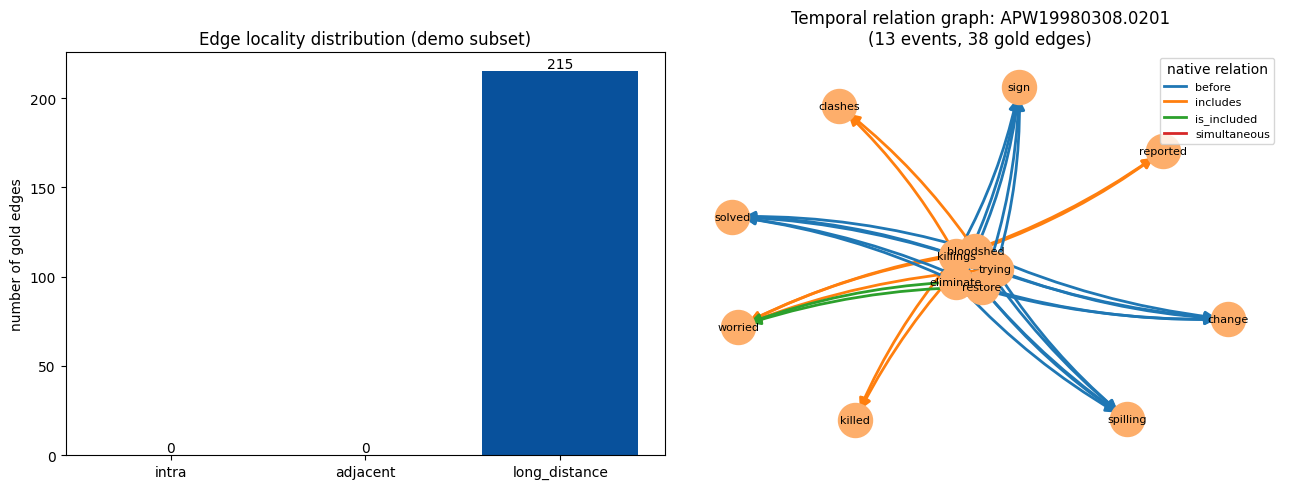


Visualized document: APW19980308.0201
Text snippet: APW19980308.0201 ->  ISTANBUL, Turkey (AP)_ Some 1,500 ethnic Albanians marched Sunday in downtown Istanbul, burning Serbian flags to protest the killings of ethnic Albanians by Serb police in southern Serb Kosovo provin ...


In [9]:
# ---- 1. Per-document summary table ----
hdr = ["doc_id", "events", "edges", "triangles", "multihop(>=3)", "long_dist"]
print(f"{hdr[0]:<28}{hdr[1]:>7}{hdr[2]:>7}{hdr[3]:>11}{hdr[4]:>15}{hdr[5]:>11}")
print("-" * 79)
for record, c in zip(records, per_doc):
    s = c["structure_event_event_informative"]
    ld = c["sentence_distance_dist"]["long_distance"]
    print(f"{record['doc_id']:<28}{c['n_events']:>7}{c['n_edges']:>7}"
          f"{s['n_triangles']:>11}{s['n_pairs_path_len_ge3']:>15}{ld:>11}")

# ---- 2. Locality distribution bar chart (aggregate) ----
sd = agg["sentence_distance_dist"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
locs = ["intra", "adjacent", "long_distance"]
ax1.bar(locs, [sd[k] for k in locs], color=["#9ecae1", "#6baed6", "#08519c"])
ax1.set_title("Edge locality distribution (demo subset)")
ax1.set_ylabel("number of gold edges")
for i, k in enumerate(locs):
    ax1.text(i, sd[k], str(sd[k]), ha="center", va="bottom")

# ---- 3. Draw one document's event-event temporal relation graph ----
# Pick the analyzed doc with the most informative event-event edges (richest structure).
best_i = max(range(len(per_doc)),
             key=lambda i: per_doc[i]["structure_event_event_informative"]["n_informative_edges"])
rec = records[best_i]
surface = {n["node_id"]: n["surface"] for n in rec["nodes"]}
ntype = {n["node_id"]: n["node_type"] for n in rec["nodes"]}

DG = nx.DiGraph()
edge_rel = {}
for e in rec["edges"]:
    u, v = e["source"], e["target"]
    if ntype.get(u) == "event" and ntype.get(v) == "event" and _is_informative(e):
        DG.add_edge(u, v)
        edge_rel[(u, v)] = e["native_relation"]
# keep the picture readable
if DG.number_of_nodes() > MAX_VIZ_NODES:
    keep = list(DG.nodes())[:MAX_VIZ_NODES]
    DG = DG.subgraph(keep).copy()

pos = nx.spring_layout(DG, seed=RANDOM_SEED, k=0.9)
rels = sorted(set(edge_rel.values()))
palette = dict(zip(rels, plt.cm.tab10.colors))
ecolors = [palette[edge_rel.get((u, v), rels[0])] for u, v in DG.edges()]

nx.draw_networkx_nodes(DG, pos, node_color="#fdae6b", node_size=600, ax=ax2)
nx.draw_networkx_labels(DG, pos, labels={n: surface.get(n, "?") for n in DG.nodes()},
                        font_size=8, ax=ax2)
nx.draw_networkx_edges(DG, pos, edge_color=ecolors, width=2, arrowsize=15,
                       connectionstyle="arc3,rad=0.08", ax=ax2)
handles = [plt.Line2D([0], [0], color=palette[r], lw=2, label=r) for r in rels]
ax2.legend(handles=handles, title="native relation", fontsize=8, loc="best")
ax2.set_title(f"Temporal relation graph: {rec['doc_id']}\n"
              f"({DG.number_of_nodes()} events, {DG.number_of_edges()} gold edges)")
ax2.axis("off")

plt.tight_layout()
plt.show()
print(f"\nVisualized document: {rec['doc_id']}")
print("Text snippet:", rec.get("doc_id"), "->", examples[best_i]["input"][:200].replace(chr(10), " "), "...")